## **Setup**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [3]:
from chatGnT.config import CFG, ensure_dirs
import chatGnT.utils as utils
import chatGnT.data.load as load
import chatGnT.data.preprocess as preprocess
import chatGnT.data.tokenize as tokenize
ensure_dirs(CFG)
import time
import math
import torch
import pandas as pd
import numpy as np
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn  # for embedding layer
from torch.utils.data import TensorDataset, DataLoader
import chatGnT.models.transformer as transformer
import chatGnT.models.positional_encoding as positional_encoding
import chatGnT.models.train as train
import chatGnT.models.evaluate as evaluate
import chatGnT.models.predict as predict

/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Load & Clean Data**

In [4]:
data = load.load_all()
df = data["ingred"]
#TODO: how make units consistent - good opportunity for test functions?


In [5]:
df_clean = preprocess.clean_recipes(df)
df_clean_filt = preprocess.filter_recipes(df_clean)


## **Make Vocab & Tokenize**

In [6]:

tokens = tokenize.recipe_to_tokens(df_clean_filt)
print(tokens[0:1])

# Alternate 2-head version
tokens_2head = tokenize.recipe_to_tokens_2head(df_clean_filt)
print(tokens_2head[0:2])


[['<amt>1 oz</amt>', '<ingred>coconut-rum</ingred>', '<amt>0.5 oz</amt>', '<ingred>amaretto</ingred>', '<amt>4 oz</amt>', '<ingred>orange-juice</ingred>', '<amt>0.5 oz</amt>', '<ingred>grenadine</ingred>']]
[[('<amt>1 oz</amt>', '<ingred>coconut-rum</ingred>'), ('<amt>0.5 oz</amt>', '<ingred>amaretto</ingred>'), ('<amt>4 oz</amt>', '<ingred>orange-juice</ingred>'), ('<amt>0.5 oz</amt>', '<ingred>grenadine</ingred>')], [('<amt>2 oz</amt>', '<ingred>light-rum</ingred>'), ('<amt>4 oz</amt>', '<ingred>ginger-beer</ingred>'), ('<amt>1 twist</amt>', '<ingred>lemon-peel</ingred>')]]


In [24]:
vocab = tokenize.make_vocab(tokens)
print(len(vocab))  # 563 classes to predict
inv_vocab = tokenize.invert_vocab(vocab)
tokens_padded = tokenize.embed_tokens(tokens, vocab)

# Alternate 2-head version
#TODO: check invert vocab
import chatGnT.data.tokenize as tokenize
vocab_amt, vocab_ingred = tokenize.make_vocab_2head(tokens_2head)
inv_vocab_amt, inv_vocab_ingred = tokenize.invert_vocab_2head(vocab_amt, vocab_ingred)
tokens_padded_2head = tokenize.embed_tokens_2head(tokens_2head, vocab_amt, vocab_ingred)


563


In [8]:
# Check vocab and padded tokens
print("Vocabulary:", vocab)
print("Padded Tokens:", tokens_padded[0])

# Check alternate 2-head version
print("Vocabulary:", vocab_amt)
print("Vocabulary:", vocab_ingred)
print("Padded Tokens:", tokens_padded_2head[0:2])

Vocabulary: {'<amt>0.125 l</amt>': 1, '<amt>0.125 shot</amt>': 2, '<amt>0.125 tsp</amt>': 3, '<amt>0.16666666666666666 glass</amt>': 4, '<amt>0.2 part</amt>': 5, '<amt>0.25 cl</amt>': 6, '<amt>0.25 cup</amt>': 7, '<amt>0.25 glass</amt>': 8, '<amt>0.25 oz</amt>': 9, '<amt>0.25 part</amt>': 10, '<amt>0.25 shot</amt>': 11, '<amt>0.25 tsp</amt>': 12, '<amt>0.25</amt>': 13, '<amt>0.3333333333333333 cup</amt>': 14, '<amt>0.3333333333333333 oz</amt>': 15, '<amt>0.3333333333333333 part</amt>': 16, '<amt>0.3333333333333333 shot</amt>': 17, '<amt>0.4 part</amt>': 18, '<amt>0.5 can</amt>': 19, '<amt>0.5 cup</amt>': 20, '<amt>0.5 gal</amt>': 21, '<amt>0.5 glass</amt>': 22, '<amt>0.5 jigger</amt>': 23, '<amt>0.5 kg</amt>': 24, '<amt>0.5 l</amt>': 25, '<amt>0.5 lb</amt>': 26, '<amt>0.5 oz</amt>': 27, '<amt>0.5 part</amt>': 28, '<amt>0.5 piece</amt>': 29, '<amt>0.5 pint</amt>': 30, '<amt>0.5 shot</amt>': 31, '<amt>0.5 slice</amt>': 32, '<amt>0.5 tsp</amt>': 33, '<amt>0.5</amt>': 34, '<amt>0.666666666

In [9]:
# tokens_tensor = [torch.tensor(r) for r in tokens_padded]
tokens_tensor = torch.tensor(tokens_padded, dtype=torch.long)
print(tokens_tensor.shape)  # torch.Size([621, 48])

# Need to have [seq_len, batch_size] for TransformerEncoder
# tokens_tensor = tokens_tensor.transpose(0, 1)
# print(tokens_tensor.shape)  # torch.Size([49, 621])


# Alternate 2-head version
# Suppose recipes_encoded is a list of (amt_ids_padded, ingred_ids_padded)
amt_seqs, ingred_seqs = zip(*tokens_padded_2head)  # unzip into two lists

# Convert to tensors
amt_tensor = torch.tensor(amt_seqs, dtype=torch.long)     # shape: (num_recipes, seq_len)
ingred_tensor = torch.tensor(ingred_seqs, dtype=torch.long)  # shape: (num_recipes, seq_len)

print(amt_tensor.shape, ingred_tensor.shape)

torch.Size([596, 25])
torch.Size([596, 13]) torch.Size([596, 13])


In [10]:
print(len(tokens_padded))
type(tokens_padded)
print(tokens_padded[0])

596
[59, 323, 27, 242, 168, 458, 27, 392, 562, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## **Get Batches**

In [11]:
# Not shifting targets since want model to attend to all tokens
# inputs = tokens_tensor
# targets = tokens_tensor
# #TODO: do need this shift now!?

# dataset = TensorDataset(inputs, targets)
# dataloader = DataLoader(
#     dataset,
#     batch_size=32,
#     shuffle=True
# )

# print(dataloader.batch_size)  # 32
# print(len(dataloader))  # 19 = 596 / 32


# Alternate 2-head version, with shfited targets

# amt_tensor, ingred_tensor: shape (num_recipes, seq_len)
# For teacher forcing, inputs are all but last token, targets are all but first token
x_amt = amt_tensor[:, :-1]
y_amt = amt_tensor[:, 1:]

x_ingred = ingred_tensor[:, :-1]
y_ingred = ingred_tensor[:, 1:]

# Create a dataset of tuples: (x_amt, x_ingred, y_amt, y_ingred)
dataset = TensorDataset(x_amt, x_ingred, y_amt, y_ingred)

# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print(dataloader.batch_size)  # 32
print(len(dataloader))        # ceil(num_recipes / batch_size)


32
19


## **Train Model**

In [12]:
embed_size=16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = transformer.TransformerModel(
    ntoken=len(vocab),
    ninp=embed_size,
    nhead=4,
    nhid=256,
    nlayers=2).to(device)
#TODO: investigate error? 

pad_id = vocab["<pad>"]
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_id)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)
#TODO: read more about schedular

TypeError: TransformerModel.__init__() got an unexpected keyword argument 'ntoken'

In [ ]:
epochs = 100  # number of epochs

# Initialize trackers
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model = None

# Early Stopping parameters
patience = 5  # Stop if no improvement for 5 epochs
trigger_times = 0 

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()

    avg_train_loss = train.train(model, dataloader, device, pad_id, optimizer, criterion, epoch, 6)
    train_losses.append(avg_train_loss)

    val_loss = evaluate.evaluate(model, dataloader, device, pad_id, criterion)
    val_losses.append(val_loss)

    print('-' * 89)
    print(
        f'Epoch {epoch} | Val Loss: {val_loss:.4f} | '
        f'Time {(time.time() - epoch_start_time)} | Val PPL: {math.exp(val_loss):.2f}')
    print('-' * 89)

    # 3. Early Stopping & Best Model Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        best_model = model
    else:
        trigger_times += 1
        print(f'No improvement. Early stopping counter: {trigger_times}/{patience}')
        if trigger_times >= patience:
            print("Early stopping triggered. Ending training.")
            break

    scheduler.step()  # adjusts learning rate
    #TODO: read more about this?


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()

## **Train Model - 2head**

In [20]:
#TODO: right now only learning from amt??


import chatGnT.models.transformer as transformer
import chatGnT.models.train as train
import chatGnT.models.evaluate as evaluate

embed_size=16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = transformer.TransformerModel(
    ntoken_amt=len(vocab_amt),
    ntoken_ingred=len(vocab_ingred),
    ninp=embed_size,
    nhead=4,
    nhid=256,
    nlayers=2).to(device)
#TODO: investigate error? 

pad_id_amt = vocab_amt["<pad>"]
pad_id_ingred = vocab_ingred["<pad>"]
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion_amt = torch.nn.CrossEntropyLoss(ignore_index=pad_id_amt)
criterion_ingred = torch.nn.CrossEntropyLoss(ignore_index=pad_id_ingred)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)
#TODO: read more about schedular

In [21]:
epochs = 100  # number of epochs

# Initialize trackers
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model = None

# Early Stopping parameters
patience = 5  # Stop if no improvement for 5 epochs
trigger_times = 0 

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()

    avg_train_loss = train.train(
        model,
        dataloader,
        device,
        pad_id_amt,
        pad_id_ingred,
        optimizer,
        criterion_amt,
        criterion_ingred,
        epoch,
        log_interval=6)
    train_losses.append(avg_train_loss)

    val_loss = evaluate.evaluate(
        model,
        dataloader,
        device,
        pad_id_amt,
        pad_id_ingred,
        criterion_amt,
        criterion_ingred)
    val_losses.append(val_loss)

    print('-' * 89)
    print(
        f'Epoch {epoch} | Val Loss: {val_loss:.4f} | '
        f'Time {(time.time() - epoch_start_time)} | Val PPL: {math.exp(val_loss):.2f}')
    print('-' * 89)

    # 3. Early Stopping & Best Model Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        best_model = model
    else:
        trigger_times += 1
        print(f'No improvement. Early stopping counter: {trigger_times}/{patience}')
        if trigger_times >= patience:
            print("Early stopping triggered. Ending training.")
            break

    scheduler.step()  # adjusts learning rate
    #TODO: read more about this?


Epoch 1 | Batch 6 | LR 0.001000 | Loss 13.0905 | PPL 484326.94 | Time 0.06s
Epoch 1 | Batch 12 | LR 0.001000 | Loss 11.0365 | PPL 62097.56 | Time 0.05s
Epoch 1 | Batch 18 | LR 0.001000 | Loss 10.9012 | PPL 54243.29 | Time 0.05s
-----------------------------------------------------------------------------------------
Epoch 1 | Val Loss: 10.6770 | Time 0.20830512046813965 | Val PPL: 43349.40
-----------------------------------------------------------------------------------------
Epoch 2 | Batch 6 | LR 0.000950 | Loss 12.4853 | PPL 264413.82 | Time 0.06s
Epoch 2 | Batch 12 | LR 0.000950 | Loss 10.5493 | PPL 38150.74 | Time 0.06s
Epoch 2 | Batch 18 | LR 0.000950 | Loss 10.4285 | PPL 33809.93 | Time 0.05s
-----------------------------------------------------------------------------------------
Epoch 2 | Val Loss: 10.1333 | Time 0.2084360122680664 | Val PPL: 25167.80
-----------------------------------------------------------------------------------------
Epoch 3 | Batch 6 | LR 0.000902 | L

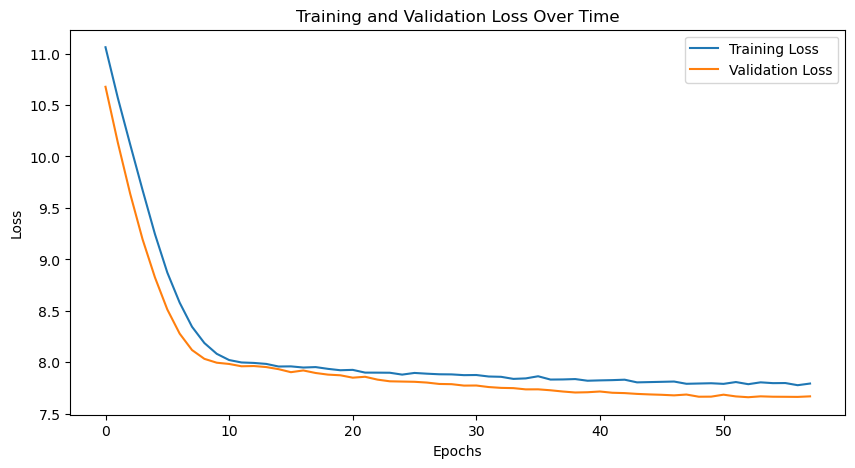

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()

## **Run with Test User Input**

In [28]:
#TODO: for now just manually making token, but need to handle actual format
# of user input


# input_mod = ['<amt>1 oz</amt>', '<ingred>gin</ingred>']
input_mod = [("<amt>1 oz</amt>", "<ingred>gin</ingred>")]

In [49]:
#TODO: consider adding unknown ingredient token for things not in vocab?
import chatGnT.models.predict as predict
predict.predict(best_model, device, pad_id_amt, pad_id_ingred, vocab_amt, vocab_ingred, inv_vocab_amt, inv_vocab_ingred, input_mod)




[('<amt>1 oz</amt>', '<ingred>gin</ingred>'),
 ('<amt>1 oz</amt>', '<ingred>orange-bitters</ingred>'),
 ('<amt>add</amt>', '<ingred>vanilla-extract</ingred>'),
 ('<end>', '<ingred>water</ingred>')]

In [ ]:
# predict.predict_groups(best_model, device, pad_id, vocab, inv_vocab, input_mod)